In [149]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as pyplot 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB 
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
import string 
import re 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 
from nltk.tokenize import word_tokenize

In [150]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [151]:
df_true = pd.read_csv('True.csv')
df_fake = pd.read_csv("Fake.csv")

In [152]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [153]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [154]:
df_true['label'] = 1 
df_fake['label'] = 0

In [155]:
print(df_true.head())
print(df_fake.head())

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  label  
0  December 31, 2017       1  
1  December 29, 2017       1  
2  December 31, 2017       1  
3  December 30, 2017       1  
4  December 29, 2017       1  
                                               title  \


In [156]:
df = pd.concat([df_true,df_fake],axis=0)
df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [157]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


In [159]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [160]:
df.isna().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [161]:
df["content"] = df["title"] + " " + df["text"]
df.head()

,title,text,subject,date,label,content
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,"As U.S. budget fight looms, Republicans flip t..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,U.S. military to accept transgender recruits o...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,Senior U.S. Republican senator: 'Let Mr. Muell...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1,FBI Russia probe helped by Australian diplomat...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1,Trump wants Postal Service to charge 'much mor...


In [175]:
df = df.drop(['title','text','subject','date'],axis=1)
df.head()

,label,content
0,1,u budget fight loom republican flip fiscal scr...
1,1,u military accept transgender recruit monday p...
2,1,senior u republican senator let mr mueller job...
3,1,fbi russia probe helped australian diplomat ti...
4,1,trump want postal service charge much amazon s...


In [176]:
df.columns

Index(['label', 'content'], dtype='object')

In [177]:
df['content'].isna().sum()

np.int64(0)

In [178]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer() 

def preprocess(text): 
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\d+','',text)
    text = re.sub(r'[^\w\s]','',text)
    text = re.sub(r'\s+',' ',text).strip()

    words = word_tokenize(text) 
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df['content'] = df['content'].apply(preprocess)

In [179]:
df['content'].head()

0    u budget fight loom republican flip fiscal scr...
1    u military accept transgender recruit monday p...
2    senior u republican senator let mr mueller job...
3    fbi russia probe helped australian diplomat ti...
4    trump want postal service charge much amazon s...
Name: content, dtype: object

In [180]:
X = df['content']
y = df['label']

In [181]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [182]:
tfidf_vector = TfidfVectorizer(ngram_range=(1,2),max_features=59999,stop_words='english')
X_train = tfidf_vector.fit_transform(X_train)
X_test = tfidf_vector.transform(X_test)

In [183]:
pac = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
pac.fit(X_train,y_train)
pac_pred = pac.predict(X_test)
accuracyScore = accuracy_score(y_test,pac_pred)
print('Accuracy:',accuracyScore)
print("Classification Report",classification_report(y_test,pac_pred))
print("Confusion Matrix",confusion_matrix(y_test,pac_pred))

Accuracy: 0.9957683741648107
Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4650
           1       0.99      1.00      1.00      4330

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

Confusion Matrix [[4627   23]
 [  15 4315]]


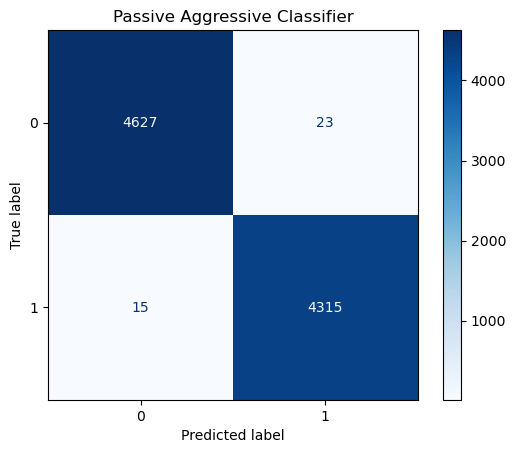

In [184]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pac_pred,
    cmap="Blues"
)

plt.title("Passive Aggressive Classifier")
plt.show()

In [185]:
nb = MultinomialNB()
nb.fit(X_train,y_train)
nb_pred = nb.predict(X_test)
print("Accuracy:",accuracy_score(y_test,nb_pred))

Accuracy: 0.9563474387527839


In [186]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [187]:
from xgboost import XGBClassifier 
xgb = XGBClassifier()
xgb.fit(X_train,y_train) 
xgb_pred = xgb.predict(X_test) 
accuracy = accuracy_score(y_test, xgb_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, xgb_pred))

print(confusion_matrix(y_test, xgb_pred))

Accuracy: 0.9974387527839643
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4650
           1       1.00      1.00      1.00      4330

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

[[4639   11]
 [  12 4318]]


In [203]:
def predict_news(news): 
    news = preprocess(news) 
    news_vector = tfidf_vector.transform([news]) 
    pac_prediction = pac.predict(news_vector)[0]
    nb_prediction = nb.predict(news_vector)[0]
    xgb_prediction = xgb.predict(news_vector)[0]

    print("Prediction Results: ")
    if pac_prediction == 1:
        print("Passive Aggressive : True News ✅")
    else:
        print("Passive Aggressive : Fake News ❌")

    if nb_prediction == 1:
        print("Naive Bayes        : True News ✅")
    else:
        print("Naive Bayes        : Fake News ❌")

    if xgb_prediction == 1:
        print("XGBoost            : True News ✅")
    else:
        print("XGBoost            : Fake News ❌")

news = str(input("Enter News Article:"))
predict_news(news)

Enter News Article: A comprehensive research paper recently published by Nepal Rastra Bank (NRB), the country’s central bank, has identified three distinct episodes of aggressive lending cycles over the past three decades that directly resulted in economic downturns. According to the central bank study, the major credit booms occurring between 1994–1996, 2008–2010, and 2020–2022 severely weakened Nepal's macroeconomic indicators. The report outlines that each period of unnatural loan expansion was followed by credit contraction, a sharp depletion of foreign exchange reserves, and a widening of the country’s current account and balance of payments deficits.  


Prediction Results: 
Passive Aggressive : Fake News ❌
Naive Bayes        : True News ✅
XGBoost            : Fake News ❌
